# Layer4 Fine-Tuning

This notebook studies partial fine-tuning of an ImageNet-pretrained ResNet-50 on the Oxford-IIIT Pet classification task.

E1 used feature extraction:

$$
\text{ImageNet Pretrained Backbone}
\rightarrow
\text{Frozen Backbone}
\rightarrow
\text{Train Classifier}
$$

E2 relaxes this constraint by allowing the final ResNet stage to adapt.

The main research question is:

> **Does adapting the highest-level ResNet representation improve performance over pure feature extraction?**

This experiment is:

$$
\boxed{\text{E2 — Layer4 Fine-Tuning}}
$$


## Experiment Configuration

The dataset protocol remains unchanged:

- 37-class Oxford-IIIT Pet classification
- Official `trainval` / `test` split
- Stratified 80/20 train-validation split
- Fixed random seed of 42
- Input resolution of $224\times224$
- Same training and evaluation transforms
- Batch size of 16
- 30 training epochs

The main experimental change is the set of trainable layers.

E1:

$$
\text{FC only}
$$

E2:

$$
\text{Layer4}+\text{FC}
$$

All earlier layers remain frozen.


In [1]:
import copy
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.datasets import OxfordIIITPet
from torchvision.models import ResNet50_Weights, resnet50


SEED = 42
DATA_ROOT = Path("../data/raw")
IMAGE_SIZE = 224
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

BATCH_SIZE = 16
NUM_WORKERS = 2
PIN_MEMORY = torch.cuda.is_available()

NUM_EPOCHS = 30
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Seed:", SEED)
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Seed: 42
Device: cuda
GPU: NVIDIA GeForce GTX 1650


## Dataset Setup

The same dataset protocol is used for E2.

The official test set remains isolated from model selection.

```mermaid
flowchart LR
    A["Oxford-IIIT Pet"] --> B["TrainVal"]
    A --> C["Test"]
    B --> D["Train"]
    B --> E["Validation"]
    D --> F["Optimization"]
    E --> G["Checkpoint Selection"]
    C --> H["Final Evaluation"]
```


In [2]:
dataset_trainval = OxfordIIITPet(
    root=DATA_ROOT,
    split="trainval",
    target_types="category",
    download=False,
)

dataset_test = OxfordIIITPet(
    root=DATA_ROOT,
    split="test",
    target_types="category",
    download=False,
)

indices = np.arange(len(dataset_trainval))
labels = np.array(dataset_trainval._labels)

train_indices, val_indices = train_test_split(
    indices,
    test_size=0.2,
    random_state=SEED,
    stratify=labels,
)

print("Train samples:", len(train_indices))
print("Validation samples:", len(val_indices))
print("Test samples:", len(dataset_test))
print("Classes:", len(dataset_trainval.classes))


Train samples: 2944
Validation samples: 736
Test samples: 3669
Classes: 37


## Image Preprocessing

The preprocessing protocol is kept unchanged.

Training:

```mermaid
flowchart LR
    A["Original Image"] --> B["RandomResizedCrop"]
    B --> C["RandomHorizontalFlip"]
    C --> D["ToTensor"]
    D --> E["ImageNet Normalization"]
    E --> F["224 × 224 Tensor"]
```

Validation and test use deterministic preprocessing:

```text
Resize → CenterCrop → ToTensor → Normalize
```

No new augmentation is introduced in E2.


In [3]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


In [4]:
class OxfordPetSubset(Dataset):
    def __init__(self, base_dataset, indices, transform=None):
        self.base_dataset = base_dataset
        self.indices = np.asarray(indices)
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, index):
        image, label = self.base_dataset[self.indices[index]]
        if self.transform is not None:
            image = self.transform(image)
        return image, label


train_dataset = OxfordPetSubset(dataset_trainval, train_indices, train_transform)
val_dataset = OxfordPetSubset(dataset_trainval, val_indices, eval_transform)
test_dataset = OxfordPetSubset(dataset_test, np.arange(len(dataset_test)), eval_transform)


In [5]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

images, labels = next(iter(train_loader))
print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Label range:", labels.min().item(), labels.max().item())


Images shape: torch.Size([16, 3, 224, 224])
Labels shape: torch.Size([16])
Label range: 1 35


## Load ImageNet-Pretrained ResNet-50

E2 starts from ImageNet-pretrained weights.

$$
\theta_0=\theta_{\text{ImageNet}}
$$

Unlike E1, the backbone is partially trainable.

```mermaid
flowchart LR
    A["Conv1"] --> B["Layer1"]
    B --> C["Layer2"]
    C --> D["Layer3"]
    D --> E["Layer4"]
    E --> F["Global Average Pool"]
    F --> G["FC"]
```

Only `Layer4` and `FC` will be updated.


In [6]:
weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights)
print("Loaded ImageNet-pretrained ResNet-50.")


Loaded ImageNet-pretrained ResNet-50.


## Replace the Classification Head

The original classifier predicts 1000 ImageNet classes.

We replace it with a 37-class classifier:

$$
\mathbb{R}^{2048}\rightarrow\mathbb{R}^{37}
$$


In [7]:
num_classes = 37
model.fc = nn.Linear(model.fc.in_features, num_classes)


## Freeze the Early Layers

E2 freezes:

- `conv1`
- `layer1`
- `layer2`
- `layer3`

and keeps trainable:

- `layer4`
- `fc`

```mermaid
flowchart LR
    A["Conv1"]:::frozen --> B["Layer1"]:::frozen
    B --> C["Layer2"]:::frozen
    C --> D["Layer3"]:::frozen
    D --> E["Layer4"]:::trainable
    E --> F["FC"]:::trainable

    classDef frozen stroke-dasharray: 5 5;
    classDef trainable stroke-width: 3;
```


In [8]:
for parameter in model.parameters():
    parameter.requires_grad = False

for parameter in model.layer4.parameters():
    parameter.requires_grad = True

for parameter in model.fc.parameters():
    parameter.requires_grad = True

model = model.to(device)


## Verify Trainable Layers

Expected:

| Component | Status |
|---|---|
| Conv1 | Frozen |
| Layer1 | Frozen |
| Layer2 | Frozen |
| Layer3 | Frozen |
| Layer4 | Trainable |
| FC | Trainable |


In [9]:
def count_parameters(module):
    total = sum(p.numel() for p in module.parameters())
    trainable = sum(p.numel() for p in module.parameters() if p.requires_grad)
    return total, trainable


components = {
    "conv1": model.conv1,
    "layer1": model.layer1,
    "layer2": model.layer2,
    "layer3": model.layer3,
    "layer4": model.layer4,
    "fc": model.fc,
}

rows = []
for name, module in components.items():
    total, trainable = count_parameters(module)
    rows.append({
        "component": name,
        "total_params": total,
        "trainable_params": trainable,
        "trainable": trainable > 0,
    })

parameter_status = pd.DataFrame(rows)
parameter_status


,component,total_params,trainable_params,trainable
0,conv1,9408,0,False
1,layer1,215808,0,False
2,layer2,1219584,0,False
3,layer3,7098368,0,False
4,layer4,14964736,14964736,True
5,fc,75813,75813,True


## Trainable Parameter Count

For E1:

$$
\theta_{\text{trainable}}=\theta_{FC}
$$

For E2:

$$
\theta_{\text{trainable}}
=
\theta_{Layer4}\cup\theta_{FC}
$$

Therefore:

$$
N_{E2}>N_{E1}
$$

while:

$$
N_{E2}<N_{\text{Full Fine-Tuning}}
$$


In [10]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Trainable ratio:      {trainable_params / total_params:.2%}")


Total parameters:     23,583,845
Trainable parameters: 15,040,549
Trainable ratio:      63.77%


## Why Fine-Tune Layer4?

CNN representations are hierarchical.

Earlier layers tend to capture lower-level patterns such as edges, corners, and textures. Deeper layers represent increasingly task-specific structures.

```mermaid
flowchart LR
    A["Early Layers"] --> B["Edges / Textures"]
    B --> C["Middle Layers"]
    C --> D["Shapes / Patterns"]
    D --> E["Layer4"]
    E --> F["High-Level Semantic Features"]
```

> **Hypothesis:** Fine-tuning Layer4 should improve adaptation to pet-breed semantics while preserving useful generic ImageNet features in earlier layers.


## Training Objective

Let:

$$
\theta=
\{
\theta_{early},
\theta_{L4},
\theta_{FC}
\}
$$

where the early parameters are frozen.

In E2:

$$
\theta_{early}^{new}=\theta_{early}^{old}
$$

while:

$$
\theta_{L4}^{new}
=
\theta_{L4}^{old}
-
\eta
\frac{\partial L}{\partial\theta_{L4}}
$$

and:

$$
\theta_{FC}^{new}
=
\theta_{FC}^{old}
-
\eta
\frac{\partial L}{\partial\theta_{FC}}
$$

Therefore, only Layer4 and the classifier adapt to the target task.


## Optimizer

We keep the baseline optimizer recipe unchanged so that the experiment isolates the effect of fine-tuning depth.

We do not introduce discriminative learning rates in E2.

Those will be studied later during the hyperparameter experiments.

$$
\eta=10^{-3}
$$

$$
\lambda=10^{-4}
$$


In [11]:
criterion = nn.CrossEntropyLoss()

optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
)


## Training Loop

The forward pass still uses the entire network, but only trainable parameters are updated.

```mermaid
flowchart LR
    A["Input"] --> B["Frozen Early Layers"]
    B --> C["Layer4"]
    C --> D["FC"]
    D --> E["Loss"]
    E --> F["Backward"]
    F --> G["Update Layer4"]
    F --> H["Update FC"]
```


In [12]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        predictions = logits.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


In [13]:
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(images)
            loss = criterion(logits, labels)

            running_loss += loss.item() * images.size(0)
            predictions = logits.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total


In [14]:
history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "learning_rate": [],
}


## Best Checkpoint

The best checkpoint is selected using validation accuracy.

```mermaid
flowchart LR
    A["Epoch"] --> B["Validation Accuracy"]
    B --> C{"Improved?"}
    C -->|Yes| D["Save E2 Checkpoint"]
    C -->|No| E["Continue Training"]
```


In [15]:
checkpoint_dir = Path("../experiments/checkpoints")
checkpoint_dir.mkdir(parents=True, exist_ok=True)

best_val_accuracy = 0.0

for epoch in range(NUM_EPOCHS):
    train_loss, train_accuracy = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_accuracy = evaluate(
        model, val_loader, criterion, device
    )

    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)
    history["learning_rate"].append(current_lr)

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy

        torch.save(
            {
                "experiment": "E2",
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_accuracy": val_accuracy,
            },
            checkpoint_dir / "resnet50_layer4_finetuning_best.pt",
        )

    scheduler.step()

    print(
        f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.2%} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.2%} | "
        f"LR: {current_lr:.2e}"
    )


Epoch [01/30] | Train Loss: 1.6153 | Train Acc: 54.21% | Val Loss: 0.6094 | Val Acc: 80.71% | LR: 1.00e-03
Epoch [02/30] | Train Loss: 0.8175 | Train Acc: 74.05% | Val Loss: 0.4631 | Val Acc: 86.41% | LR: 9.97e-04
Epoch [03/30] | Train Loss: 0.6673 | Train Acc: 79.99% | Val Loss: 0.3907 | Val Acc: 87.36% | LR: 9.89e-04
Epoch [04/30] | Train Loss: 0.6142 | Train Acc: 81.79% | Val Loss: 0.4017 | Val Acc: 87.23% | LR: 9.76e-04
Epoch [05/30] | Train Loss: 0.4996 | Train Acc: 85.12% | Val Loss: 0.2864 | Val Acc: 91.03% | LR: 9.57e-04
Epoch [06/30] | Train Loss: 0.4508 | Train Acc: 86.72% | Val Loss: 0.2766 | Val Acc: 91.71% | LR: 9.33e-04
Epoch [07/30] | Train Loss: 0.4036 | Train Acc: 87.70% | Val Loss: 0.3064 | Val Acc: 90.22% | LR: 9.05e-04
Epoch [08/30] | Train Loss: 0.3697 | Train Acc: 88.55% | Val Loss: 0.3071 | Val Acc: 91.03% | LR: 8.72e-04
Epoch [09/30] | Train Loss: 0.3441 | Train Acc: 89.64% | Val Loss: 0.2238 | Val Acc: 92.66% | LR: 8.35e-04
Epoch [10/30] | Train Loss: 0.3406 | 

## Load the Best E2 Checkpoint

After training, restore the checkpoint with the highest validation accuracy before evaluating on the official test set.


In [16]:
checkpoint = torch.load(
    checkpoint_dir / "resnet50_layer4_finetuning_best.pt",
    map_location=device,
)

model.load_state_dict(checkpoint["model_state_dict"])

best_epoch = checkpoint["epoch"]

print("Best epoch:", best_epoch)
print("Best validation accuracy:", f"{checkpoint['val_accuracy']:.2%}")


Best epoch: 21
Best validation accuracy: 94.70%


## Learning Curves

The training and validation curves help us determine whether allowing Layer4 to adapt improves optimization and whether additional trainable parameters introduce overfitting.


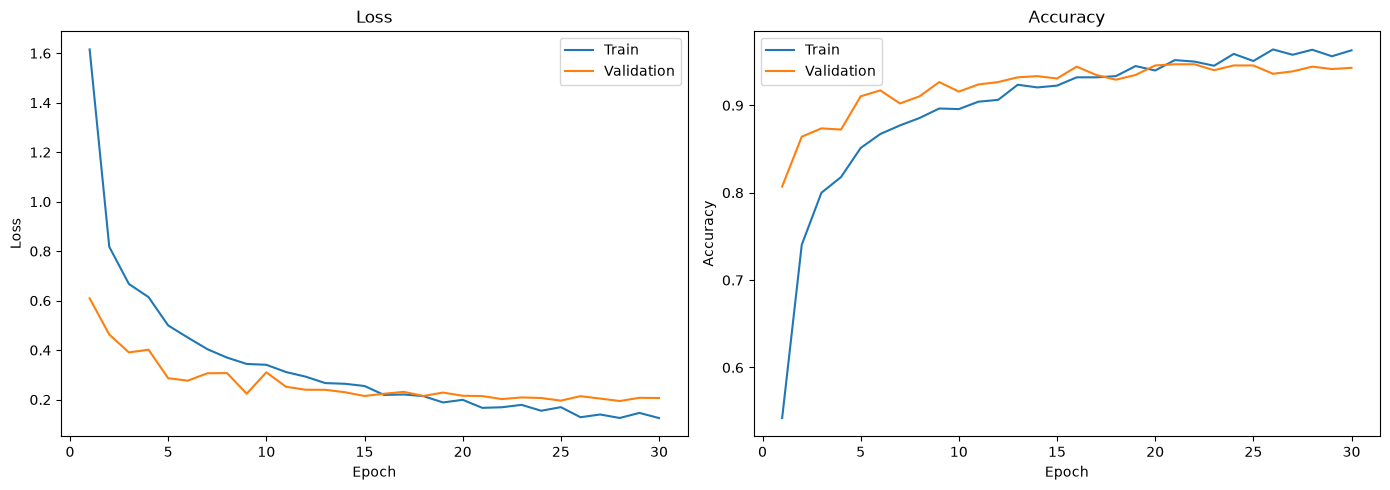

In [17]:
epochs = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, history["train_loss"], label="Train")
axes[0].plot(epochs, history["val_loss"], label="Validation")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(epochs, history["train_accuracy"], label="Train")
axes[1].plot(epochs, history["val_accuracy"], label="Validation")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()


## Validation Evaluation

The validation set is used to select the best E2 checkpoint.

We report:

- validation loss
- validation accuracy
- best epoch


In [18]:
best_val_loss, best_val_accuracy = evaluate(
    model=model,
    loader=val_loader,
    criterion=criterion,
    device=device,
)

print(f"Best Validation Loss: {best_val_loss:.4f}")
print(f"Best Validation Accuracy: {best_val_accuracy:.2%}")
print("Best Epoch:", best_epoch)


Best Validation Loss: 0.2142
Best Validation Accuracy: 94.70%
Best Epoch: 21


## Final Evaluation on the Test Set

After selecting the E2 checkpoint using validation performance, we evaluate it once on the official test set.

The test set is not used for model selection or hyperparameter tuning.


In [19]:
test_loss, test_accuracy = evaluate(
    model=model,
    loader=test_loader,
    criterion=criterion,
    device=device,
)

print(f"E2 Test Loss: {test_loss:.4f}")
print(f"E2 Test Accuracy: {test_accuracy:.2%}")


E2 Test Loss: 0.3668
E2 Test Accuracy: 91.20%


## E1 vs E2 Comparison

E1 and E2 use the same ImageNet initialization.

The difference is the amount of the backbone that is allowed to adapt.

### E1

$$
\theta_{\text{backbone}}=\text{constant}
$$

Only the classifier is trained.

### E2

$$
\theta_{Layer4}
\text{ and }
\theta_{FC}
\text{ are trainable}
$$

The experimental question is:

> **Does adapting high-level ImageNet features improve performance beyond frozen feature extraction?**


## E2 Baseline Result

The result records:

- trainable parameter count
- best epoch
- validation accuracy
- validation loss
- test accuracy
- test loss
- fine-tuning strategy


In [20]:
e2_result = pd.DataFrame([{
    "experiment": "E2",
    "model": "ResNet-50",
    "initialization": "ImageNet",
    "trainable_params": trainable_params,
    "epochs": NUM_EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "best_epoch": best_epoch,
    "best_val_accuracy": best_val_accuracy,
    "best_val_loss": best_val_loss,
    "test_accuracy": test_accuracy,
    "test_loss": test_loss,
    "strategy": "Layer4 + FC Fine-Tuning",
}])

e2_result


,experiment,model,initialization,trainable_params,epochs,batch_size,learning_rate,weight_decay,best_epoch,best_val_accuracy,best_val_loss,test_accuracy,test_loss,strategy
0,E2,ResNet-50,ImageNet,15040549,30,16,0.001,0.0001,21,0.947011,0.214195,0.911965,0.366784,Layer4 + FC Fine-Tuning


## Save E2 Experiment Result

The experiment result is saved immediately after final test evaluation.


In [21]:
results_dir = Path("../experiments/results")
results_dir.mkdir(parents=True, exist_ok=True)

e2_result.to_csv(
    results_dir / "e2_layer4_finetuning.csv",
    index=False,
)

results_path = results_dir / "experiment_results.csv"

if results_path.exists():
    existing_results = pd.read_csv(results_path)
    existing_results = existing_results[
        existing_results["experiment"] != "E2"
    ]
    experiment_results = pd.concat(
        [existing_results, e2_result],
        ignore_index=True,
    )
else:
    experiment_results = e2_result.copy()

experiment_results.to_csv(
    results_path,
    index=False,
)

experiment_results


,experiment,model,initialization,trainable_params,epochs,batch_size,learning_rate,weight_decay,best_epoch,best_val_accuracy,best_val_loss,test_accuracy,test_loss,strategy
0,E0,ResNet-50,Random,23583845,30,16,0.001,0.0001,30,0.338315,2.317437,0.288907,2.500295,NaN
1,E1,ResNet-50,ImageNet,75813,30,16,0.001,0.0001,16,0.937500,0.226684,0.911420,0.292235,Feature Extraction
2,E2,ResNet-50,ImageNet,15040549,30,16,0.001,0.0001,21,0.947011,0.214195,0.911965,0.366784,Layer4 + FC Fine-Tuning


# Conclusions

E2 extends Feature Extraction by allowing the final ResNet stage to adapt.

The experiment is:

$$
\boxed{
\text{ImageNet Pretraining}
+
\text{Layer4 Fine-Tuning}
}
$$

while earlier layers remain frozen.

The central comparison is:

$$
\boxed{
E1:\text{FC only}
\quad\text{vs}\quad
E2:\text{Layer4 + FC}
}
$$

The next experiment increases the adaptation depth:

> **E3 — Layer3 + Layer4 Fine-Tuning**
